# Vector Quantized Variational Autoencoder (VQVAE)

> *Neural Discrete Representation Learning* - van den Oord et al., 2017

## Improvements over baseline
| Improvement | Why |
|-------------|-----|
| **Residual blocks** in encoder/decoder | Captures finer details without extra depth |
| **EMA codebook updates** | More stable than gradient, reduces codebook collapse |
| **Cosine LR scheduler** | Smoother convergence, avoids end-of-training oscillations |

## Loss (EMA removes the codebook loss term)
```
L = MSE(x, x_hat)  +  beta * MSE(z_e, sg[z_q])    (commitment only)
```

## Step 1 - Imports & configuration

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {torch.cuda.get_device_name(0)} | VRAM: {total:.1f} GB")

BATCH_SIZE     = 16
EPOCHS         = 7
LR             = 2e-4
EMBEDDING_DIM  = 32   # D (reduced from 64)
NUM_EMBEDDINGS = 256  # K (reduced from 512)
BETA           = 0.25
EMA_DECAY      = 0.99
NUM_RES_BLOCKS = 1    # reduced from 2
USE_AMP        = True # mixed precision: halves VRAM usage


Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Ti | VRAM: 8.6 GB


## Step 2 - Dataset (FashionMNIST)

In [2]:
transform = transforms.Compose([
    transforms.Pad(2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
val_dataset   = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
print(f'Train: {len(train_dataset):,} | Val: {len(val_dataset):,}')

Train: 60,000 | Val: 10,000


## Step 3 - Residual Block

Two convolutions with a **skip connection** (add the input back).
The network learns corrections on top of the identity - much easier to optimise.
```
x --> Conv3x3 --> ReLU --> Conv3x3 --> (+) --> ReLU --> out
 \__________________________________________/
```

In [3]:
class ResidualBlock(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(x + self.net(x))

## Step 4 - Encoder

Two strided convolutions for downsampling, then residual blocks to refine features.
```
(B,  1, 32, 32) --> Conv s2 --> (B, 32, 16, 16)
                --> Conv s2 --> (B, 64,  8,  8)
                --> ResBlock x2 --> (B, 64,  8,  8)
                --> Conv 3x3 --> (B,  D,  8,  8)  = z_e
```

In [4]:
class Encoder(nn.Module):
    def __init__(self, in_channels, embedding_dim, num_res_blocks=2):
        super().__init__()
        self.downsample = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=4, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), nn.ReLU(inplace=True),
        )
        self.res_blocks = nn.Sequential(*[ResidualBlock(64) for _ in range(num_res_blocks)])
        self.proj = nn.Conv2d(64, embedding_dim, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.proj(self.res_blocks(self.downsample(x)))


enc = Encoder(1, EMBEDDING_DIM, NUM_RES_BLOCKS)
print(f'Encoder output: {enc(torch.zeros(4, 1, 32, 32)).shape}')  # (4, 64, 8, 8)

Encoder output: torch.Size([4, 32, 8, 8])


## Step 5 - Vector Quantizer with EMA updates

### Why EMA instead of gradient-based codebook loss?
With gradients, the codebook and encoder compete - unstable.
With EMA, the codebook is updated **directly** as a running average of the encoder
outputs assigned to each entry. No gradient flows into the codebook.

### EMA update rule (each training step)
```
n_i = count of encoder outputs assigned to entry i
s_i = sum of those outputs
N_i <-- gamma*N_i + (1-gamma)*n_i   (EMA count)
m_i <-- gamma*m_i + (1-gamma)*s_i   (EMA sum)
e_i = m_i / N_i                     (updated codebook vector)
```
N and m are **buffers** - the optimizer ignores them.

In [5]:
class VectorQuantizerEMA(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, beta=0.25, decay=0.99, eps=1e-5):
        super().__init__()
        self.K, self.D = num_embeddings, embedding_dim
        self.beta, self.decay, self.eps = beta, decay, eps

        embed = torch.randn(num_embeddings, embedding_dim)
        self.register_buffer('embedding',        embed)
        self.register_buffer('ema_cluster_size', torch.zeros(num_embeddings))
        self.register_buffer('ema_embed_avg',    embed.clone())

    def forward(self, z_e):
        B, D, H, W = z_e.shape
        z_flat = z_e.permute(0, 2, 3, 1).contiguous().view(-1, D)  # (N, D)

        # L2 distance: ||a-b||^2 = ||a||^2 + ||b||^2 - 2*a*b^T
        d = (
            z_flat.pow(2).sum(1, keepdim=True)
            + self.embedding.pow(2).sum(1)
            - 2 * z_flat @ self.embedding.t()
        )  # (N, K)
        indices_flat = d.argmin(dim=1)        # (N,)
        indices = indices_flat.view(B, H, W)  # (B, H, W)

        if self.training:
            one_hot = F.one_hot(indices_flat, self.K).float()  # (N, K)
            n_i = one_hot.sum(0)           # (K,)
            s_i = one_hot.t() @ z_flat     # (K, D)
            self.ema_cluster_size = self.decay * self.ema_cluster_size + (1 - self.decay) * n_i
            self.ema_embed_avg    = self.decay * self.ema_embed_avg    + (1 - self.decay) * s_i
            # Laplace smoothing: avoids division by zero for unused entries
            n_smooth = ((self.ema_cluster_size + self.eps)
                        / (self.ema_cluster_size.sum() + self.K * self.eps)
                        * self.ema_cluster_size.sum())
            self.embedding = self.ema_embed_avg / n_smooth.unsqueeze(1)

        z_q_flat = self.embedding[indices_flat]                    # (N, D)
        z_q = z_q_flat.view(B, H, W, D).permute(0, 3, 1, 2)      # (B, D, H, W)

        # Commitment loss only (EMA handles the codebook)
        loss = self.beta * F.mse_loss(z_q.detach(), z_e)

        # Straight-through: forward=z_q, backward=gradient through z_e
        z_q = z_e + (z_q - z_e).detach()
        return z_q, loss, indices


vq = VectorQuantizerEMA(NUM_EMBEDDINGS, EMBEDDING_DIM, BETA, EMA_DECAY)
vq.train()
z_e_dummy = torch.randn(4, EMBEDDING_DIM, 8, 8)
z_q_dummy, loss_dummy, idx_dummy = vq(z_e_dummy)
print(f'z_q: {z_q_dummy.shape} | indices: {idx_dummy.shape} | loss: {loss_dummy.item():.4f}')

z_q: torch.Size([4, 32, 8, 8]) | indices: torch.Size([4, 8, 8]) | loss: 580.5453


## Step 6 - Decoder

Mirror of the encoder: residual blocks first, then transposed convolutions.
```
(B,  D,  8,  8) --> Conv --> ResBlock x2 --> ConvT s2 --> ConvT s2 --> Tanh
                --> (B, 64, 8, 8)         --> (B,32,16,16) --> (B,1,32,32)
```

In [6]:
class Decoder(nn.Module):
    def __init__(self, embedding_dim, out_channels, num_res_blocks=2):
        super().__init__()
        self.proj = nn.Conv2d(embedding_dim, 64, kernel_size=3, stride=1, padding=1)
        self.res_blocks = nn.Sequential(*[ResidualBlock(64) for _ in range(num_res_blocks)])
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, out_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def forward(self, z_q):
        return self.upsample(self.res_blocks(self.proj(z_q)))


dec = Decoder(EMBEDDING_DIM, out_channels=1, num_res_blocks=NUM_RES_BLOCKS)
print(f'Decoder output: {dec(z_q_dummy).shape}')  # (4, 1, 32, 32)

Decoder output: torch.Size([4, 1, 32, 32])


## Step 7 - Full VQVAE model

In [7]:
class VQVAE(nn.Module):
    def __init__(self, in_channels, embedding_dim, num_embeddings, beta, decay, num_res_blocks):
        super().__init__()
        self.encoder = Encoder(in_channels, embedding_dim, num_res_blocks)
        self.vq      = VectorQuantizerEMA(num_embeddings, embedding_dim, beta, decay)
        self.decoder = Decoder(embedding_dim, in_channels, num_res_blocks)

    def forward(self, x):
        z_e               = self.encoder(x)
        z_q, vq_loss, idx = self.vq(z_e)
        x_hat             = self.decoder(z_q)
        return x_hat, vq_loss, idx

    @torch.no_grad()
    def encode(self, x):
        _, _, indices = self.vq(self.encoder(x))
        return indices

    @torch.no_grad()
    def decode_indices(self, indices):
        B, H, W = indices.shape
        z_q = self.vq.embedding[indices.view(-1)]
        z_q = z_q.view(B, H, W, -1).permute(0, 3, 1, 2)
        return self.decoder(z_q)


model = VQVAE(
    in_channels=1, embedding_dim=EMBEDDING_DIM, num_embeddings=NUM_EMBEDDINGS,
    beta=BETA, decay=EMA_DECAY, num_res_blocks=NUM_RES_BLOCKS,
).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
x_dummy = torch.randn(4, 1, 32, 32).to(device)
x_hat, vq_loss, idx = model(x_dummy)
print(f'x_hat: {x_hat.shape} | codes: {idx.shape}')

Parameters: 251,361
x_hat: torch.Size([4, 1, 32, 32]) | codes: torch.Size([4, 8, 8])


## Step 8 - Training with cosine LR scheduler

Cosine annealing smoothly decays LR from `LR` to ~0 over all epochs:
```
LR_t = eta_min + 0.5*(LR - eta_min)*(1 + cos(pi*t/T_max))
```
Watch `codebook_usage`: if it drops sharply -> codebook collapse (EMA helps prevent this).

In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler    = torch.amp.GradScaler(enabled=USE_AMP)  # AMP scaler

history = {"train_recon":[], "train_vq":[], "val_recon":[], "val_vq":[], "codebook_usage":[], "lr":[]}


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_recon, total_vq, total_usage = 0.0, 0.0, 0
    with (torch.enable_grad() if train else torch.no_grad()):
        for x, _ in loader:
            x = x.to(device)
            # AMP autocast: runs forward pass in float16 -> 2x less VRAM
            with torch.amp.autocast(device_type=device.type, enabled=USE_AMP):
                x_hat, vq_loss, indices = model(x)
                recon_loss = F.mse_loss(x_hat, x)
                loss = recon_loss + vq_loss
            if train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()   # scaled backward for float16 stability
                scaler.step(optimizer)
                scaler.update()
            total_recon += recon_loss.item()
            total_vq    += vq_loss.item()
            total_usage += indices.unique().numel()
    n = len(loader)
    return total_recon / n, total_vq / n, total_usage // n


for epoch in range(1, EPOCHS + 1):
    tr_r, tr_vq, usage = run_epoch(train_loader, train=True)
    va_r, va_vq, _     = run_epoch(val_loader,   train=False)
    scheduler.step()
    lr = scheduler.get_last_lr()[0]
    for k, v in zip(["train_recon","train_vq","val_recon","val_vq","codebook_usage","lr"],
                    [tr_r, tr_vq, va_r, va_vq, usage, lr]):
        history[k].append(v)
    if epoch % 5 == 0:
        used = torch.cuda.memory_allocated() / 1e9 if device.type == "cuda" else 0
        print(f"Epoch {epoch:02d}/{EPOCHS} | recon {tr_r:.4f}/{va_r:.4f} | "
              f"vq {tr_vq:.4f}/{va_vq:.4f} | codebook {usage}/{NUM_EMBEDDINGS} | "
              f"lr {lr:.2e} | VRAM used {used:.1f}GB")
    else:
        print(f"Epoch {epoch:02d}/{EPOCHS} | recon {tr_r:.4f}/{va_r:.4f} | "
              f"vq {tr_vq:.4f}/{va_vq:.4f} | codebook {usage}/{NUM_EMBEDDINGS} | lr {lr:.2e}")


Epoch 01/7 | recon 0.0447/0.0201 | vq 0.0079/0.0021 | codebook 72/256 | lr 1.90e-04
Epoch 02/7 | recon 0.0178/0.0162 | vq 0.0021/0.0021 | codebook 90/256 | lr 1.63e-04
Epoch 03/7 | recon 0.0151/0.0145 | vq 0.0020/0.0019 | codebook 119/256 | lr 1.23e-04
Epoch 04/7 | recon 0.0137/0.0133 | vq 0.0019/0.0020 | codebook 158/256 | lr 7.84e-05
Epoch 05/7 | recon 0.0127/0.0126 | vq 0.0020/0.0020 | codebook 184/256 | lr 3.85e-05 | VRAM used 9.8GB
Epoch 06/7 | recon 0.0121/0.0121 | vq 0.0020/0.0021 | codebook 199/256 | lr 1.09e-05
Epoch 07/7 | recon 0.0118/0.0119 | vq 0.0020/0.0020 | codebook 211/256 | lr 1.00e-06


## Step 9 - Training curves

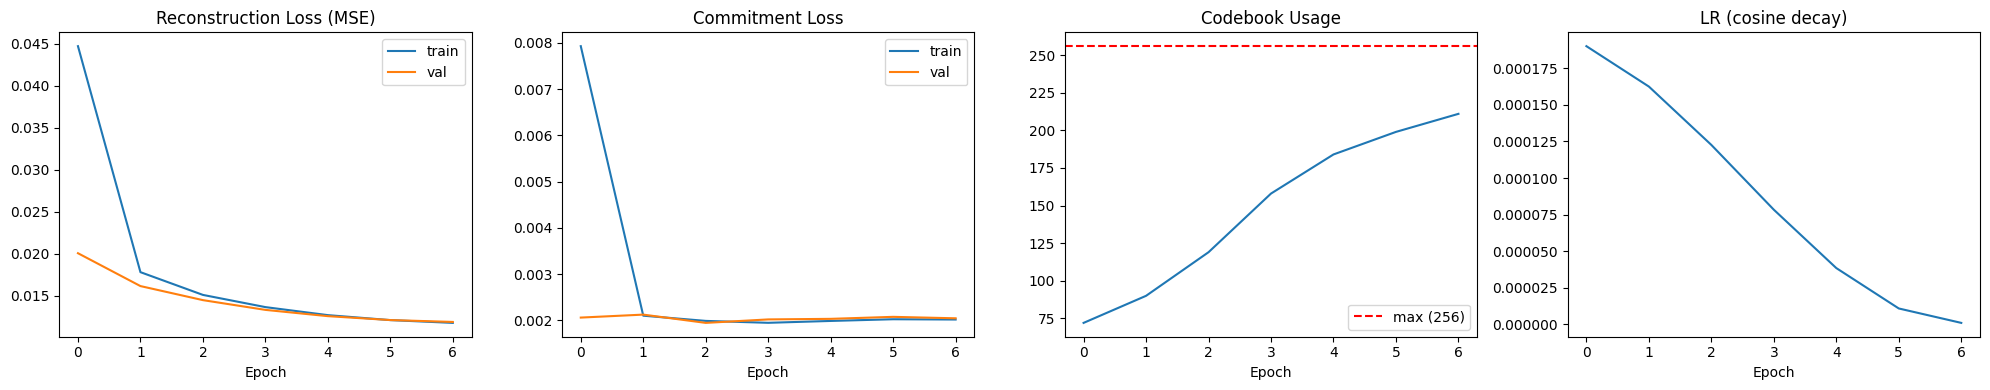

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].plot(history['train_recon'], label='train'); axes[0].plot(history['val_recon'], label='val')
axes[0].set_title('Reconstruction Loss (MSE)'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history['train_vq'], label='train'); axes[1].plot(history['val_vq'], label='val')
axes[1].set_title('Commitment Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()
axes[2].plot(history['codebook_usage'])
axes[2].axhline(NUM_EMBEDDINGS, color='r', linestyle='--', label=f'max ({NUM_EMBEDDINGS})')
axes[2].set_title('Codebook Usage'); axes[2].set_xlabel('Epoch'); axes[2].legend()
axes[3].plot(history['lr']); axes[3].set_title('LR (cosine decay)'); axes[3].set_xlabel('Epoch')
plt.tight_layout(); plt.show()

## Step 10 - Reconstruction quality

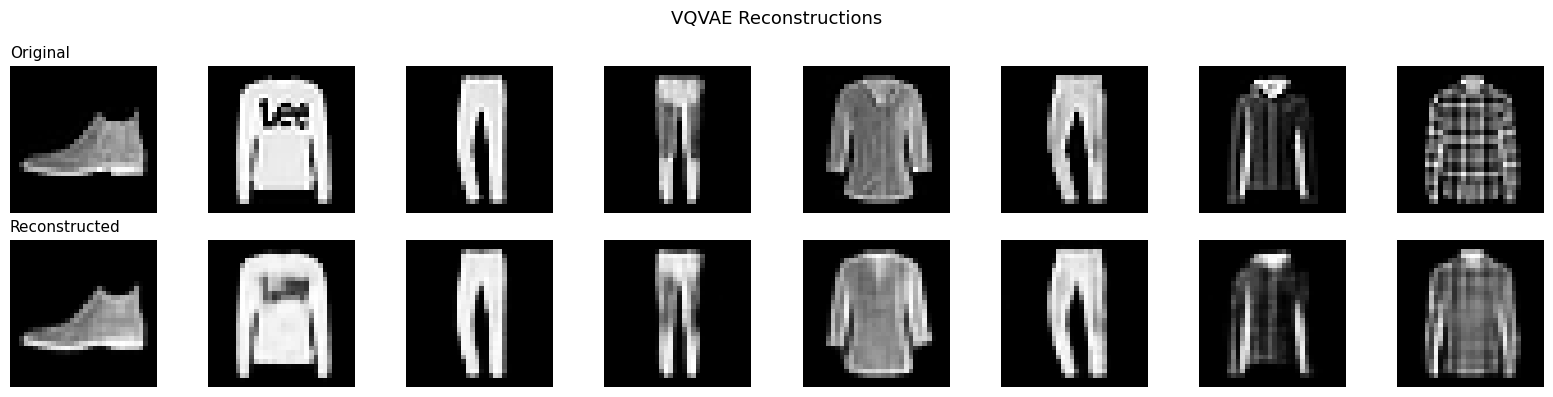

In [10]:
model.eval()
x_sample, _ = next(iter(val_loader))
x_sample = x_sample[:8].to(device)
with torch.no_grad():
    x_recon, _, _ = model(x_sample)
to_img = lambda t: (t.cpu() * 0.5 + 0.5).clamp(0, 1)
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(to_img(x_sample[i]).squeeze(), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(to_img(x_recon[i]).squeeze(),  cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_title('Original', loc='left', fontsize=11)
axes[1, 0].set_title('Reconstructed', loc='left', fontsize=11)
plt.suptitle('VQVAE Reconstructions', fontsize=13); plt.tight_layout(); plt.show()

## Step 11 - Discrete code maps

Each image compresses to an **8x8 grid of integers** in [0, K-1].
DALL-E 1 uses exactly this: a Transformer generates these token maps from text,
then the VQVAE decoder renders them into images.

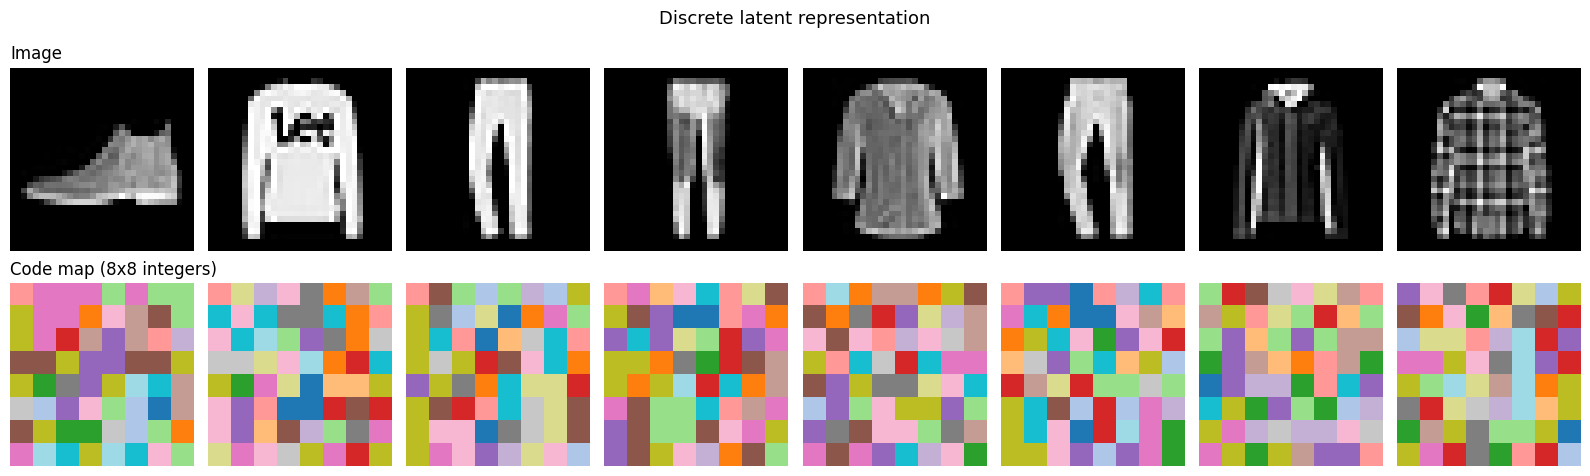

Compression: 32x32=1024 --> 8x8=64 integers in [0,255]  (16x)


In [11]:
with torch.no_grad():
    codes = model.encode(x_sample)  # (8, 8, 8)
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i in range(8):
    axes[0, i].imshow(to_img(x_sample[i]).squeeze(), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(codes[i].cpu().numpy(), cmap='tab20', vmin=0, vmax=NUM_EMBEDDINGS); axes[1, i].axis('off')
axes[0, 0].set_title('Image', loc='left')
axes[1, 0].set_title('Code map (8x8 integers)', loc='left')
plt.suptitle('Discrete latent representation', fontsize=13); plt.tight_layout(); plt.show()
print(f'Compression: 32x32=1024 --> 8x8=64 integers in [0,{NUM_EMBEDDINGS-1}]  ({1024//64}x)')

## Step 12 - Code-space interpolation

Discrete space: no linear interpolation. Instead, spatially mix the code maps
of two images and decode the hybrid.

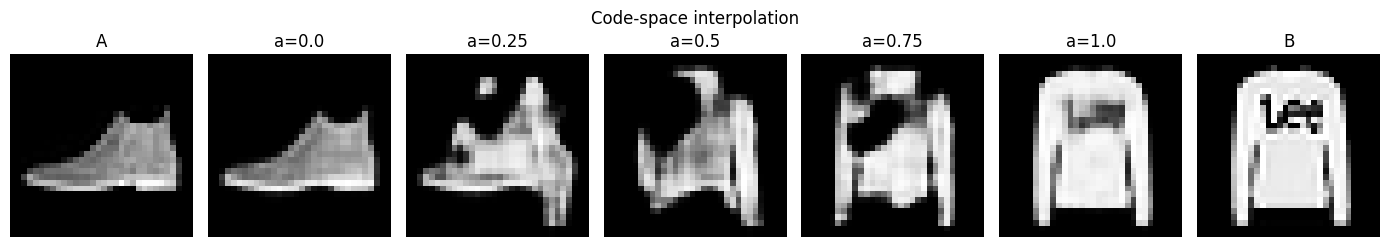

In [12]:
with torch.no_grad():
    codes_all = model.encode(x_sample)
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, len(alphas)+2, figsize=(14, 2.5))
axes[0].imshow(to_img(x_sample[0]).squeeze(), cmap='gray'); axes[0].set_title('A'); axes[0].axis('off')
axes[-1].imshow(to_img(x_sample[1]).squeeze(), cmap='gray'); axes[-1].set_title('B'); axes[-1].axis('off')
for j, alpha in enumerate(alphas):
    mask = (torch.rand(8, 8) < alpha).to(device)
    mixed = torch.where(mask, codes_all[1], codes_all[0]).unsqueeze(0)
    with torch.no_grad():
        hybrid = model.decode_indices(mixed)
    axes[j+1].imshow(to_img(hybrid[0]).squeeze(), cmap='gray')
    axes[j+1].set_title(f'a={alpha}'); axes[j+1].axis('off')
plt.suptitle('Code-space interpolation', fontsize=12); plt.tight_layout(); plt.show()

## Summary

| Component | Role |
|-----------|------|
| `ResidualBlock` | Skip connections -- better detail, easier optimisation |
| `Encoder` | Downsamples 32x32->8x8, refines with residual blocks |
| `VectorQuantizerEMA` | Nearest-neighbour lookup; codebook updated by EMA |
| Straight-through | Copies gradient from decoder to encoder past the argmin |
| Commitment loss | Pulls encoder outputs toward codebook entries |
| `Decoder` | Refines with residual blocks, upsamples 8x8->32x32 |
| Cosine scheduler | Smooth LR decay for clean final convergence |

## What's next?
Train a **PixelCNN or Transformer** on the 8x8 code maps as a prior -> unconditional generation.
That is exactly how DALL-E 1 works:
```
Text --> Transformer --> code map (8x8) --> VQVAE decoder --> image
```